![SWDB](img/swdb_logo.jpg)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

# Trusting Code — LLM Coding & Verification

For the rest of SWDB you will repeatedly find yourself verifying code written by colleagues, found online, or generated by LLMs. In this workshop we'll practice that role on an LLM-generated analysis.

The analysis code lives in `code/workshops/src/`. It was run ahead of time and saved intermediate artifacts (parquet / JSON) under `/scratch`. The figures below are generated from these artifacts (the full re-run takes a looooong time). Skim through the first set of figures to get a sense of how the analysis worked, then consider the verification questions and answer them (and any other questions that come to mind!) to convince yourself that this analysis is sound.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

#### Objective

_This is a small portion of the full prompt used to generate this analysis:_

We are generating an analysis of tuning to drifting gratings (and natural stimuli) in optical physiology data (2-photon imaging with the GCaMP6s calcium indicator) from the Allen Institute V1 DeepDive data set, to be combined with inferred cell types and connectivity from the EM portion of the data set.

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

## 1 — Orientation tuning curve for one ROI

For the first step of analysis, the LLM was asked to select a "most responsive" neuron to drifting gratings and to compute an orientation tuning curve.

</div>

In [9]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the analysis package importable regardless of launch directory
for cand in [os.getcwd(), os.path.join(os.getcwd(), 'code', 'workshops'),
             os.path.dirname(os.getcwd()), '/root/capsule/code/workshops']:
    if os.path.isdir(os.path.join(cand, 'src')):
        sys.path.insert(0, cand)
        break

from src import artifacts, metrics, tuning_curves as tc

S1, S2 = artifacts.STEP1_DIR, artifacts.STEP2_DIR
meta = artifacts.load_json(S1 / 'selected_roi.json')
ROI, PLANE = meta['roi_id'], meta['plane']
print(f"Selected ROI {ROI} ({PLANE}), SNR={meta['snr']:.2f}")

Selected ROI 16 (plane-3), SNR=7.96


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

This first figure displays the output of the first step, which we will verify. The code can be found in src/LLM_step1_output.py.

</div>

<img src="img/LLM_output1.png" width="900">

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

Here are some plotting tools to help you explore and visualize the data.

This is the whole-session ΔF/F trace of this ROI with each stimulus epoch shaded, to show when drifting gratings were shown relative to other stimuli.

</div>

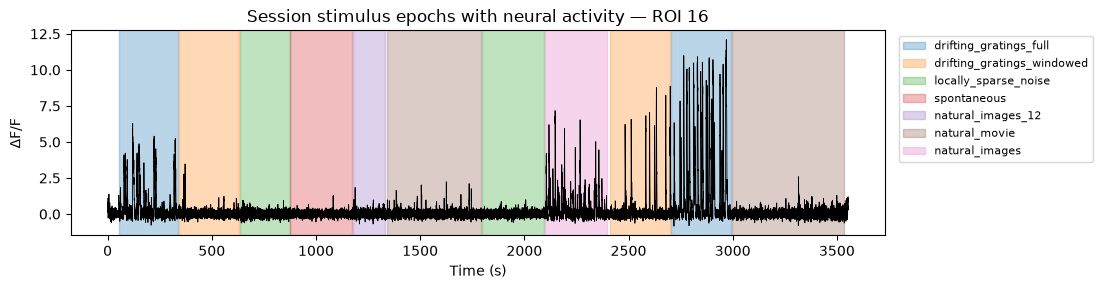

In [10]:
trace = artifacts.load_table(S1 / 'roi_trace.parquet')
epochs = artifacts.load_table(S1 / 'epochs.parquet')
dg = artifacts.load_table(S1 / 'stim_dg.parquet')
ts, dff = trace['time'].values, trace['dff'].values

names = list(epochs['stim_name'].unique())
ep_colors = dict(zip(names, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(ts, dff, color='black', lw=0.6)
for name in names:
    sub = epochs[epochs['stim_name'] == name]
    for i, (a, b) in enumerate(zip(sub['start_time'], sub['stop_time'])):
        ax.axvspan(a, b, color=ep_colors[name], alpha=0.3, label=name if i == 0 else None)
ax.set_xlabel('Time (s)'); ax.set_ylabel(r'$\Delta$F/F')
ax.set_title(f'Session stimulus epochs with neural activity — ROI {ROI}')
ax.legend(bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

Zooming into the drifting-gratings block, we can shade each trial by its grating orientation. The lower panel zooms to a ~25 s chunk so that individual trial responses are visible.

</div>

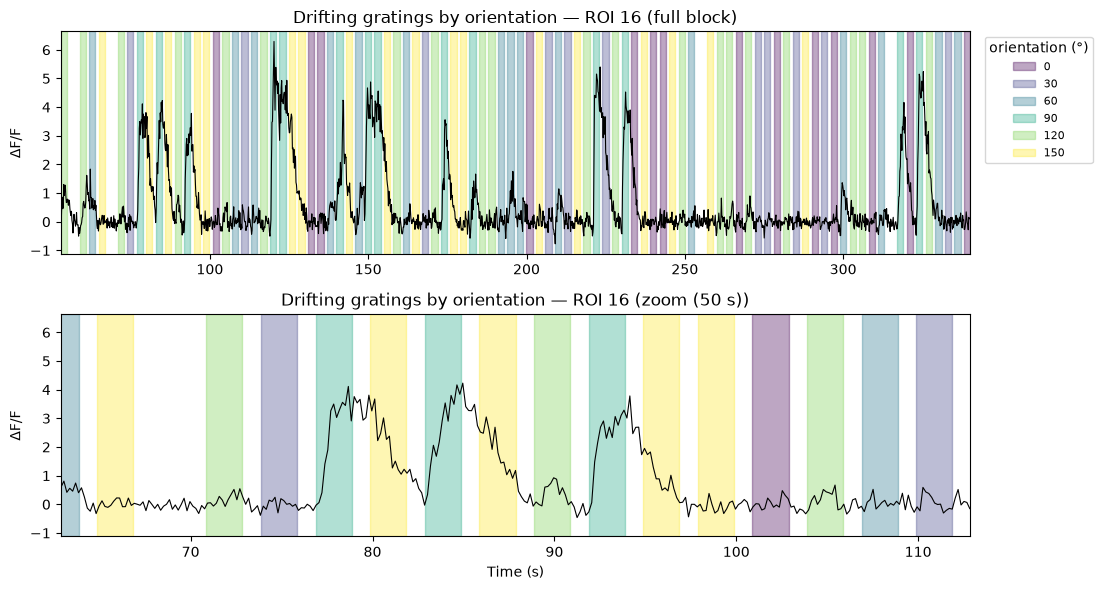

In [11]:
dgep = epochs[epochs['stim_name'] == 'drifting_gratings_full'].iloc[0]
pres = dg[dg['start_time'] <= dgep['stop_time']]
oris = sorted(pres['orientation'].unique())
o_colors = dict(zip(oris, plt.colormaps['viridis'].resampled(len(oris)).colors))

def shade_orientation(ax):
    for o in oris:
        sub = pres[pres['orientation'] == o]
        for i, (a, b) in enumerate(zip(sub['start_time'], sub['stop_time'])):
            ax.axvspan(a, b, color=o_colors[o], alpha=0.35, label=int(o) if i == 0 else None)

blk = (ts > dgep['start_time']) & (ts < dgep['stop_time'])
z0 = dgep['start_time'] + 10.0
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
for ax, xlim, title in [(axes[0], (dgep['start_time'], dgep['stop_time']), 'full block'),
                        (axes[1], (z0, z0 + 50), 'zoom (50 s)')]:
    ax.plot(ts[blk], dff[blk], color='black', lw=0.8)
    shade_orientation(ax)
    ax.set_xlim(xlim); ax.set_ylabel(r'$\Delta$F/F')
    ax.set_title(f'Drifting gratings by orientation — ROI {ROI} ({title})')
axes[1].set_xlabel('Time (s)')
axes[0].legend(title='orientation (°)', bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

The orientation tuning curve is built by averaging responses across trials. The LLM purports to select a window relative to the peak of the PSTH.

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

## Verification Questions — single-ROI analysis

**Data & ROI selection**
1. How is the data loaded? What is *zero* time, and what are the time units?
2. How does the code select the most responsive neuron to drifting gratings? Is the selected ROI robustly responsive?

**Response window & baseline**

3. Is the tuning curve reasonable for the chosen roi?
4. How was the response window chosen, and how was baselining done? What is the timecourse and shape of the response? What do you think of the window's duration and shape?
5. Should the same response window be used across all ROIs (from average behavior) rather than fit per-ROI? What happens if a peak is sought in non-responsive data?

**Conditions & orientation**

6. How are multiple temporal / spatial frequencies handled?
7. Is the conversion of direction to orientation correct? Is the direction polar plot correctly generated?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

## 2 — Population and metric exploration

Beyond one ROI, the pipeline computed tuning curves for every ROI (`roi_tuning.parquet`) and derived per-ROI metrics: an orientation-selectivity index (OSI), and a variation of this the global orientation selectivity index (gOSI), and von Mises tuning width (`roi_metrics.parquet`). The original code is provided in ```LLM_step2_3_output.py``` as a reference although you do not have to read it in trying to verify the output. WARNING: This code takes a long time to run, the extracted results are already save for you so there is no need to run this code. 

The LLM was then asked to plot OSI versus tuning width, resulting in this output plot:

</div>

<img src="../workshops/img/Tuning_OSI_output.png" width="900">

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

We can visualize a random sample of computed orientation tuning curves across the population.

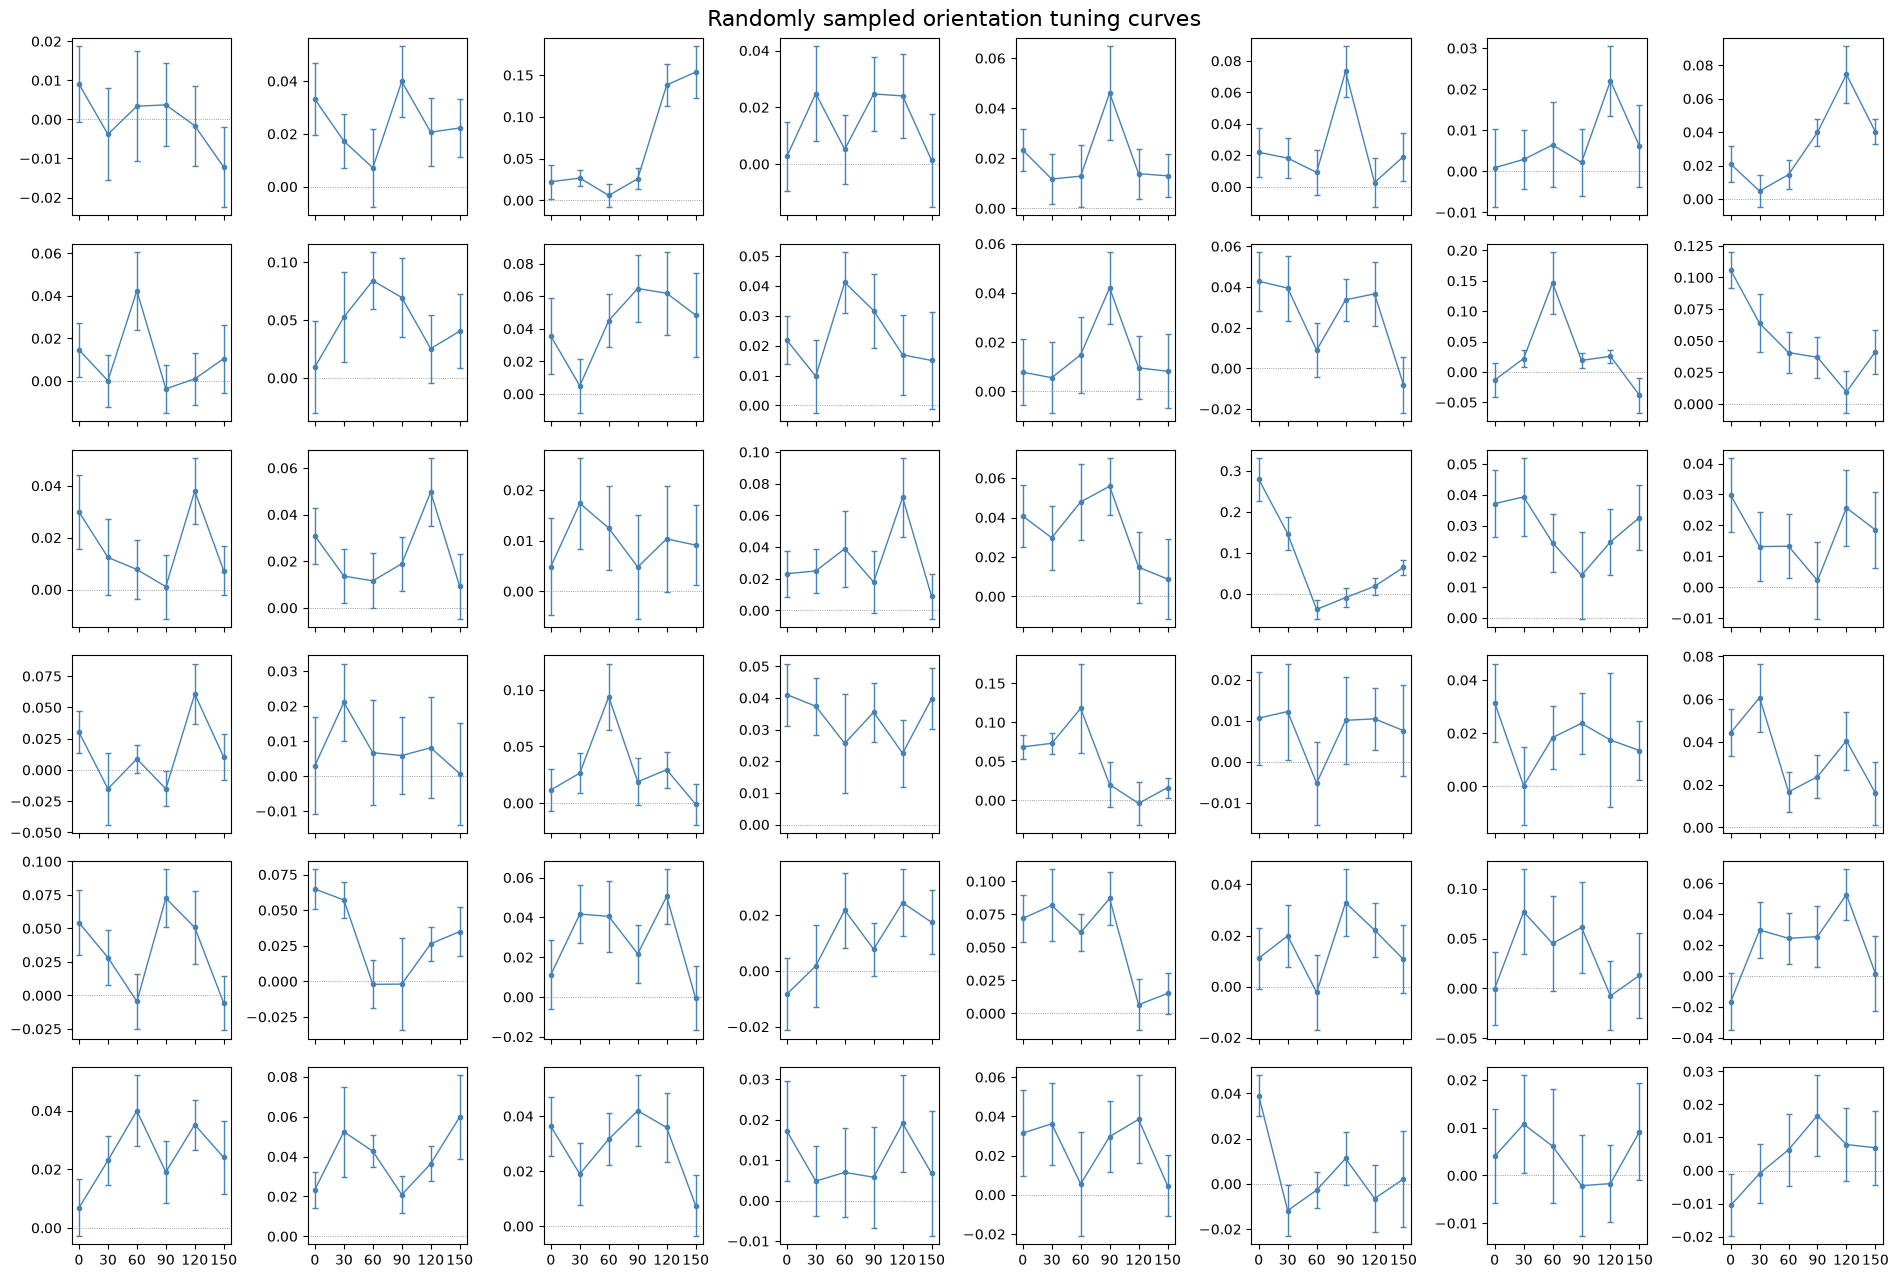

In [12]:
df_tuning = artifacts.load_table(S2 / 'roi_tuning.parquet')
rng = np.random.default_rng(42)
idx = rng.choice(len(df_tuning), size=48, replace=False)

fig, axes = plt.subplots(6, 8, figsize=(19, 13), sharex=True)
for k, ax in zip(idx, axes.flat):
    t = tc.reshape_tuning(df_tuning.iloc[[k]])
    ax.errorbar(t['orientation'], t['mean_response'], yerr=t['sem'],
                fmt='o-', color='steelblue', ms=3, lw=1, capsize=2)
    ax.axhline(0, color='gray', ls=':', lw=0.6)
    ax.set_xticks(t['orientation'])
fig.suptitle('Randomly sampled orientation tuning curves', fontsize=16)
plt.tight_layout(); plt.show()

In [16]:
df_metrics = artifacts.load_table(S2 / 'roi_metrics.parquet')
df_metrics

,session_name,column,volume,plane,roi,roi_idx,plane_name,pref_ori,pref_ori_vec,OSI,gOSI,tuning_width,ori_mean_0,ori_mean_30,ori_mean_60,ori_mean_90,ori_mean_120,ori_mean_150
0,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,0,0,plane-0,60.0,70.340816,0.097751,0.066989,NaN,0.065912,0.060365,0.101206,0.082177,0.056372,0.083182
1,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,1,1,plane-0,90.0,99.761318,0.564299,0.304446,NaN,0.036072,0.020966,0.101568,0.129508,0.088379,0.088818
2,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,2,2,plane-0,30.0,49.605781,0.365127,0.153137,19.102858,0.072569,0.216437,0.104925,0.142514,0.100657,0.093228
3,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,4,3,plane-0,60.0,58.867205,0.879025,0.482293,32.126415,0.090063,0.104926,0.393460,0.094587,0.082980,0.025332
4,409828_2018-11-06_14-02-59_filtered_2026-04-09...,2,1,0,5,4,plane-0,30.0,71.844791,0.052006,0.065664,NaN,0.046663,0.113269,0.112910,0.074586,0.102070,0.099461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39402,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,182,116,plane-5,150.0,136.515932,1.377273,0.599488,19.102906,-0.008836,-0.001110,-0.003598,0.010204,0.000171,0.022674
39403,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,207,117,plane-5,60.0,15.313365,0.119358,0.356146,19.102892,0.016662,0.008529,0.020187,-0.015035,-0.000219,0.015882
39404,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,217,118,plane-5,60.0,60.758573,-17.728397,0.419006,36.957554,-0.011377,0.007791,0.011792,-0.007681,0.008146,-0.013202
39405,409828_2018-12-14_14-47-35_filtered_2026-04-09...,1,5,5,263,119,plane-5,150.0,133.974365,3.477471,0.566016,19.102860,-0.000678,-0.000525,-0.004971,0.004771,-0.013453,0.008985


<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

## Verification Questions — population & metrics

8. Does the extracted tuning for our "most responsive" cell above (session 409828_2018-11-06_14-02-59_filtered_2026-04-09_04-59-00, plane-03, ROI 16) look the same in the batch processed data?

9. How should noisy, essentially non-responsive neurons be handled — and what constitutes "responsive"?

10. Is the OSI metric correctly implemented? Is the range of values reasonable? How might you constrain, or what alternatives exist?

11. Can you verify the fitting of the tuning curve with the von Mises function?

12. Does the relationship between orientation-selectivity index and tuning width make sense?

</div>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF;">

## 3 — Tuning by EM cell type (exploratory)

Finally, functional metrics are coregistered with EM-inferred cell types (`coregistration_1196.feather`, `soma_and_cell_type_1196.feather`). Per-cell-type orientation tuning curves are peak-normalized and aligned to the preferred orientation (thin = individual cells, thick = mean ± SEM), alongside mean gOSI and tuning width per type.

</div>

In [17]:
from src import coreg
cache = S2 / 'roi_cell_type.parquet'
if cache.exists():
    mf_ct = artifacts.load_table(cache)
else:
    try:
        import src.pipeline as pl
        mf_ct = pl.run_step4()
    except FileNotFoundError:
        mf_ct = None
        print('EM dataset (v1dd_1196) not attached — cell-type figure skipped.')

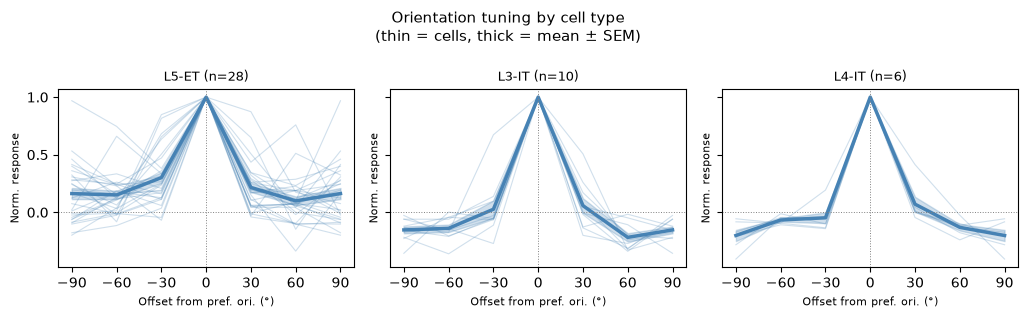

In [18]:
if mf_ct is not None:
    x_plot = np.array([-90, -60, -30, 0, 30, 60, 90])
    cell_types = (mf_ct['cell_type'].value_counts().loc[lambda s: s >= 3].index.tolist())
    ncols = min(4, len(cell_types)); nrows = int(np.ceil(len(cell_types) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2),
                             sharex=True, sharey=True, squeeze=False)
    for ax, ct_name in zip(axes.ravel(), cell_types):
        sub = mf_ct[mf_ct['cell_type'] == ct_name]
        curves = [tc.align_and_normalize(r[metrics.ORI_MEAN_COLS].values.astype(float))
                  for _, r in sub.iterrows()]
        for y in curves:
            ax.plot(x_plot, y, color='steelblue', alpha=0.25, lw=0.8)
        mean_tc = np.nanmean(curves, axis=0); sem_tc = np.nanstd(curves, axis=0) / np.sqrt(len(curves))
        ax.plot(x_plot, mean_tc, color='steelblue', lw=2.5)
        ax.fill_between(x_plot, mean_tc - sem_tc, mean_tc + sem_tc, color='steelblue', alpha=0.25)
        ax.axhline(0, color='gray', ls=':', lw=0.7); ax.axvline(0, color='gray', ls=':', lw=0.7)
        ax.set_title(f'{ct_name} (n={len(sub)})', fontsize=9)
        ax.set_xticks(x_plot); ax.set_xlabel('Offset from pref. ori. (°)', fontsize=8)
        ax.set_ylabel('Norm. response', fontsize=8)
    for ax in axes.ravel()[len(cell_types):]:
        ax.set_visible(False)
    fig.suptitle('Orientation tuning by cell type\n(thin = cells, thick = mean ± SEM)', fontsize=11)
    plt.tight_layout(); plt.show()

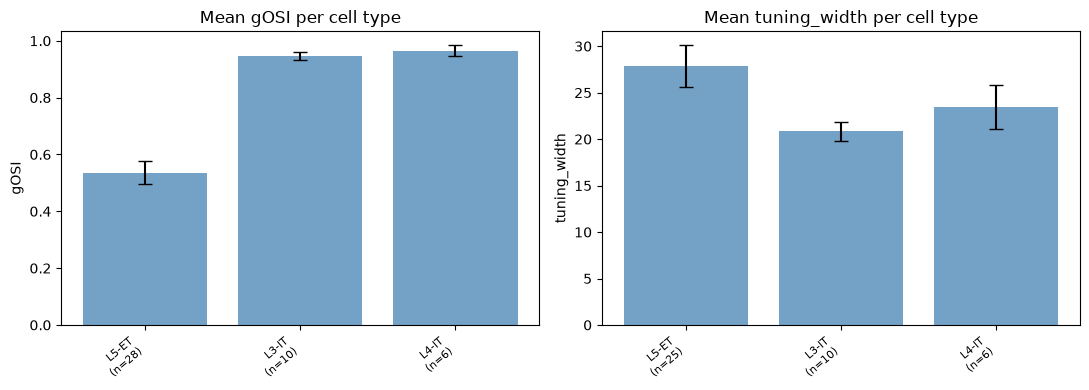

            gOSI              tuning_width             
            mean    sem count         mean    sem count
cell_type                                              
L3-IT      0.945  0.014    10       20.831  1.050    10
L4-IT      0.966  0.018     6       23.500  2.377     6
L5-ET      0.535  0.040    28       27.833  2.262    25
L5-IT      0.796  0.144     2       19.103  0.000     2


In [19]:
if mf_ct is not None:
    summary = coreg.cell_type_summary(mf_ct)
    cell_types = (mf_ct['cell_type'].value_counts().loc[lambda s: s >= 3].index.tolist())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, metric in zip(axes, ['gOSI', 'tuning_width']):
        vals = [mf_ct.loc[mf_ct['cell_type'] == c, metric].dropna() for c in cell_types]
        x = np.arange(len(cell_types))
        ax.bar(x, [v.mean() for v in vals], yerr=[v.sem() for v in vals],
               capsize=5, color='steelblue', alpha=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{c}\n(n={len(v)})' for c, v in zip(cell_types, vals)],
                           rotation=40, ha='right', fontsize=8)
        ax.set_ylabel(metric); ax.set_title(f'Mean {metric} per cell type')
    plt.tight_layout(); plt.show()
    print(summary.to_string())

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #f5ffd8;">

## Verification Questions — cell types

11. Did the coregistration merge correctly? What key and join type were used, and what were the table dimensions before and after? (A cell is uniquely identified by column + volume + plane + roi — not `roi_idx`. Some EM cells have multiple functional entries across planes or sessions.)
12. Do the per-cell-type tuning curves look right? How are they averaged, normalized, and aligned? Do the metrics agree with the curves? Are cell-type differences expected from the literature?

</div>